# Aprenentatge no supervisat

Al contrari que el supervisat, el no supervisat treballa en datasets `no etiquetats`, és a dir sense `target`. 

L'objectiu és classificar les observacions, als distints grups els podem posar després, o no, etiquetes. 

Com a part del procés es poden detectar dades que no corresponen a cap classe. Això són anomalíes o `outliers`. De vegades els outliers molesten per al bon funcionament dels models, de vegades podem utilitzar aquests algorismes per detectar outliers per a altres algorismes supervisats i de vegades estarem fen els models perquè el que ens interessa són precisament detectar anomalies. 


Els sistemes de *clustering* funcionen avaluant la similitud o **afinitat** entre diferents observacions o respecte a un grup ja existent. Com major siga esta afinitat, més probable serà que s'integreguen en el mateix conjunt. El seu propòsit fonamental es dividix en dos objectius complementaris:

1. **Alta cohesió:** Aconseguir la màxima similitud possible entre els elements que formen part d'un mateix clúster.
2. **Baix acoblament:** Garantir la mínima relació o afinitat entre els components de clústers diferents.

La gran majoria d'estos algorismes comparteixen un caràcter **iteratiu** perquè s'enfoquen com a problemes d'optimització. El procés habitual seguix estos passos:

* Es partix d'una **solució inicial** (que pot ser completament aleatòria), assignant les observacions a diferents grups.
* Esta distribució inicial es va **refinant pas a pas** en successives iteracions.
* Alguns mètodes exigeixen definir el nombre de clústers per endavant, mentre que uns altres el poden modificar en temps d'execució (per exemple, fusionant grups).
* El procés finalitza quan s'arriba a un punt d'estabilitat —on l'assignació de les dades ja no canvia— o quan es complix un requisit mínim de qualitat.


## Tipus principals d'algorismes

### 1. K-Means (Basat en distàncies)

Cada clúster està definit per un **centroide** (el seu punt central). Cada dada s'assigna al grup del centroide que té més a prop. A continuació, es recalculen les coordenades dels centroides fent la mitjana aritmètica de totes les dades d'eixe clúster. El cicle es repeteix fins que cap dada canvia de grup. Requereix fixar prèviament el nombre de clústers ($k$) i triar uns centres inicials de manera arbitrària.

### 2. FCM: Fuzzy C-Means (Basat en lògica difusa)

És una evolució de K-Means. En lloc de vincular una dada a un únic clúster de forma absoluta, utilitza funcions matemàtiques per a calcular la **probabilitat de pertinença** a cada grup. Finalment, cada observació s'associa al clúster on esta funció de pertinença prenga el valor màxim.

### 3. DBSCAN (Basat en densitat)

Agrupa en un mateix clúster aquells punts situats en **zones d'alta concentració** de dades (amb molts veïns pròxims). Per contra, classifica com a valors atípics o *outliers* tots aquells punts situats en regions aïllades o de baixa densitat.

### 4. Clústering jeràrquic

Genera una estructura de grups en forma d'arbre que es pot visualitzar mitjançant un **dendrograma**, on la base o arrel és el conjunt complet de dades i els nivells inferiors formen particions cada vegada més específiques. Pot funcionar de dos formes:

* **Aglomeratiu (*bottom-up*):** Es comença considerant cada dada com un clúster independent i s'aniran unint progressivament de baix a dalt.
* **Divisiu (*top-down*):** Es comença amb un únic clúster que abasta tot el *dataset* i s'anirà dividint successivament de dalt a baix.

## K-Means

Aquest algorisme de `clustering` es basa en la distància. El que es fa es definir un `centroid` que és el punt central d'un cluster. Cada observació es assignada al cluster que té el centroid més proper. 

El centroid és la mitjana aritmètica de totes les observacions del cluster. 

La dificultat d'aquest algorisme és determinar els centroids:

- Es trien k dades com a centroids. 
- S'assigna cada dada al centroid més proper, per tant tenim k grups.
- Si en el pas anterior hi ha algun canvi de grup, el torna a obtenir el centroid de cada grup que ha canviat i es torna al pas anterior. 

https://www.unioviedo.es/compnum/labs/new/kmeans.html



In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from IPython.display import HTML

# 1. Generació de dades sintètiques en 2 dimensions
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0)

# 2. Configuració prèvia de K-means per capturar els passos
k = 4
max_iter = 10

# Guardarem els centroides de cada iteració per animar-los
centroids_history = []
labels_history = []

# Inicialització aleatòria dels centroides (pertorbats per forçar iteracions)
init_centroids = X[np.random.choice(X.shape[0], k, replace=False)] + np.random.normal(scale=3.0, size=(k, X.shape[1]))
current_centroids = init_centroids.copy()

for i in range(max_iter):
    # Assignar clústers basats en els centroides actuals
    kmeans = KMeans(n_clusters=k, init=current_centroids, n_init=1, max_iter=1)
    kmeans.fit(X)
    
    labels_history.append(kmeans.labels_)
    centroids_history.append(kmeans.cluster_centers_)
    
    # Comprovar si els centroides han deixat de moure'ixer (convergent)
    if np.allclose(current_centroids, kmeans.cluster_centers_):
        break
    current_centroids = kmeans.cluster_centers_

# 3. Configuració de la figura de Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
scat = ax.scatter(X[:, 0], X[:, 1], c=labels_history[0], cmap='viridis', s=50, alpha=0.7)
cent_scat = ax.scatter(centroids_history[0][:, 0], centroids_history[0][:, 1], 
                       c='red', marker='X', s=200, edgecolor='black', label='Centroides')

ax.set_title('Evolució de K-Means (Pas 0)', fontsize=14)
ax.set_xlabel('Característica 1')
ax.set_ylabel('Característica 2')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# 4. Funció d'actualització per a l'animació
def update(frame):
    # Actualitzar els colors dels punts segons l'assignació del clúster
    scat.set_array(np.array(labels_history[frame]))
    
    # Actualitzar la posició dels centroides
    cent_scat.set_offsets(centroids_history[frame])
    
    ax.set_title(f'Evolució de K-Means - Iteració {frame + 1}', fontsize=14)
    return scat, cent_scat

# Crear l'animació
anim = FuncAnimation(fig, update, frames=len(centroids_history), interval=800, blit=False)

# Tancar la figura estàtica per evitar que es mostri doble al notebook
plt.close()

# 5. Mostrar l'animació directament al Jupyter Notebook
HTML(anim.to_jshtml())

La distància normalment és `euclídea`, que en 2 dimensions és bàsicament la hipotenusa del teorema de Pitàgores. 

No obstant es pot utilitzar la distància `Manhathan`, que és la suma dels catets. 

Per a fer clustering en conjunts de paraules es pot utilitzar la distància de `Hamming` que miren en dos cadenes de caracteris el número de caraters diferents. 

La distància `Levenshtein` és la quantitat mínima d'operacions a realitzar en una cadena de caracters per transformar-la en l'altra. És un càlcul computacionalment complex.

### Avaluar k-Means

La qualitat del resultat es basa en la suma dels quadrats de les distàncies respecte al centroid del cluster. La mesura es diu `SSD` (`Sum of Squared Distancies`) o `SSE` (`Sum of Squared Errors`) o també `inèrcia`.

Precisament l'algorisme el que tracta és de minimitzar aquesta mesura de manera iterativa. Però pot ser que no trobe un mínim global, sols un mínim global. 

> La simulació anterior de vegades mostra com no es troba un mínim global si els centroids inicials aleatoris no cauen en un bon lloc. 

Els clusters tenen una frontera recta i formen diagrames `Voronoi`. Per tant, un resultat perfecte requereix que siguen `linealment separables`. És possible que sigen linealment separables i que no es puguen separar amb aquest algorisme, ja que amb atributs no normalitzats o distants, poden semblar ser de l'altre cluster. 

Amb clusters `globulars` funciona molt millor que allargats o amb formes irregulars. Si són allargats en distintes direccions pot no ser possible separar els clústers. 

> Al següent exemple es generen grups amb make_classification que ens permet generar clústers amb geometries orientades o lleugerament lineals (més enllà dels clústers purament esfèrics o globulars dels blobs clàssics). D'altra banda, si el nostre objectiu és demostrar les limitacions evidents de K-Means, la documentació de Scikit-Learn ens ofereix generadors d'estructures no lineals i no convexes —com make_moons per a formes de mitja lluna o make_gaussian_quantiles per a anells concèntrics—, on l'algorisme fracassa perquè les seves fronteres de Voronoi basades en distàncies euctidianes no s'hi poden adaptar.

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from IPython.display import HTML

# 1. Generar dues subpoblacions amb make_classification per sumar 5 clústers en total (2 + 3)
X1, _ = make_classification(
    n_samples=150, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_classes=2, 
    n_clusters_per_class=1, 
    class_sep=3.0, 
    #random_state=42
)
# Desplacem el primer grup lleugerament per evitar que se superposin massa
X1 = X1 + np.array([-3.0, 0.0])

X2, _ = make_classification(
    n_samples=150, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_classes=3, 
    n_clusters_per_class=1, 
    class_sep=2.0, 
    #random_state=24
)
# Desplacem el segon grup a una altra zona de l'espai 2D
X2 = X2 + np.array([3.0, 0.0])

# Unim ambdós conjunts en una sola matriu de 300 mostres i 2 dimensions
X = np.vstack([X1, X2])

# Total de clústers desitjats (2 + 3 = 5)
k = 5

# 2. Configuració de K-means i captura d'històric
max_iter = 15 
centroids_history = []
labels_history = []

#np.random.seed(42)
init_indices = np.random.choice(X.shape[0], k, replace=False)
current_centroids = X[init_indices]

for i in range(max_iter):
    kmeans = KMeans(n_clusters=k, init=current_centroids, n_init=1, max_iter=1)
    kmeans.fit(X)
    
    labels_history.append(kmeans.labels_)
    centroids_history.append(kmeans.cluster_centers_)
    
    if np.allclose(current_centroids, kmeans.cluster_centers_):
        break
    current_centroids = kmeans.cluster_centers_

# 3. Configuració de la figura i creació del Meshgrid per a Voronoi
fig, ax = plt.subplots(figsize=(9, 7))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.15),
                     np.arange(y_min, y_max, 0.15))

# 4. Funció d'actualització
def update(frame):
    ax.clear()  
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    current_centers = centroids_history[frame]
    
    # Calcular les regions de Voronoi per a la iteració actual
    distances = np.linalg.norm(np.c_[xx.ravel(), yy.ravel()][:, np.newaxis] - current_centers, axis=2)
    Z = np.argmin(distances, axis=1).reshape(xx.shape)
    
    # Dibuixar el fons de Voronoi
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', zorder=0)
    
    # Dibuixar els punts de dades combinats
    ax.scatter(X[:, 0], X[:, 1], c=labels_history[frame], cmap='viridis', s=40, edgecolor='k', alpha=0.9, zorder=1)
    
    # Dibuixar els centroides
    ax.scatter(current_centers[:, 0], current_centers[:, 1], 
               c='red', marker='X', s=250, edgecolor='black', label='Centroides', zorder=2)
    
    ax.set_title(f'K-Means amb {k} Clústers Combinats (2+3 Make-Classification) - Iteració {frame + 1}', fontsize=14)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

# Crear l'animació
anim = FuncAnimation(fig, update, frames=len(centroids_history), interval=1000, blit=False)

plt.close()

# 5. Mostrar l'animació
HTML(anim.to_jshtml())

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from IPython.display import HTML

# Nombre de clústers
k = 2

# 1. Generació de dades amb make_moons per a 2 clústers irregulars
X, _ = make_moons(n_samples=300, noise=0.08)

# 2. Configuració de K-means i captura d'històric
max_iter = 15 
centroids_history = []
labels_history = []


init_indices = np.random.choice(X.shape[0], k, replace=False)
current_centroids = X[init_indices]

for i in range(max_iter):
    kmeans = KMeans(n_clusters=k, init=current_centroids, n_init=1, max_iter=1)
    kmeans.fit(X)
    
    labels_history.append(kmeans.labels_)
    centroids_history.append(kmeans.cluster_centers_)
    
    if np.allclose(current_centroids, kmeans.cluster_centers_):
        break
    current_centroids = kmeans.cluster_centers_

# 3. Configuració de la figura i creació del Meshgrid per a Voronoi
fig, ax = plt.subplots(figsize=(9, 7))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.15),
                     np.arange(y_min, y_max, 0.15))

# 4. Funció d'actualització
def update(frame):
    ax.clear()  
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    current_centers = centroids_history[frame]
    
    # Calcular les regions de Voronoi per a la iteració actual
    distances = np.linalg.norm(np.c_[xx.ravel(), yy.ravel()][:, np.newaxis] - current_centers, axis=2)
    Z = np.argmin(distances, axis=1).reshape(xx.shape)
    
    # Dibuixar el fons de Voronoi
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', zorder=0)
    
    # Dibuixar els punts de dades de make_moons
    ax.scatter(X[:, 0], X[:, 1], c=labels_history[frame], cmap='viridis', s=40, edgecolor='k', alpha=0.9, zorder=1)
    
    # Dibuixar els centroides
    ax.scatter(current_centers[:, 0], current_centers[:, 1], 
               c='red', marker='X', s=250, edgecolor='black', label='Centroides', zorder=2)
    
    ax.set_title(f'K-Means amb Make-Moons (k={k}) i Voronoi - Iteració {frame + 1}', fontsize=14)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

# Crear l'animació
anim = FuncAnimation(fig, update, frames=len(centroids_history), interval=1000, blit=False)

plt.close()

# 5. Mostrar l'animació
HTML(anim.to_jshtml())

### Elecció de centroids

Hi ha varis plantejaments:

* Triar el centroid amb més distància al quadrat de la resta de tots els punts i els següent el més llunyà d'aquest. Funciona bé, però té tendència a triar `outliers`. Si els detectem i els llevem primer, és un bon algorisme. 
* Triar a l'atzar però afavorint punts llunyans del centroid anterior. Això evita triar `outliers`. 


### Elecció de k

> En aquest punt i els exemples següents anem a triar la manera més simple i normalment no aconsellada. Després expliquem perquè i al final d'aquest capítol veurem en pràctica mètodes més sofisticats.

El que es pot fer és executar l'algorisme amb distints valors i triar el que menor `SSD` dona. Si es fa una gràfica del `SSD` en funció de `k` es diu `elbow graphic`. Quant es troba que ja no millora molt (el colze) es triar el valor menor. Normalment interessa la menor quantitat possible de clusters.  

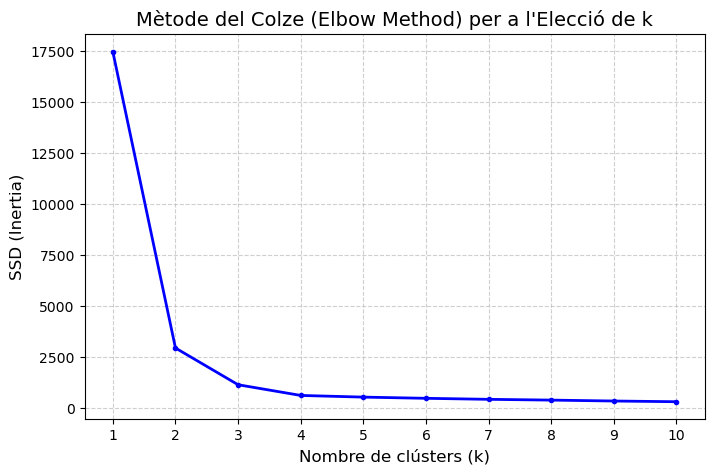

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# 1. Generació de dades amb
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0)

# 2. Càlcul del SSD (Inertia) per a diferents valors de k (Elbow Method)
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# 3. Representació gràfica del mètode del colze (Elbow Graphic)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, marker='o', linestyle='-', color='b', linewidth=2, markersize=3)
ax.set_title("Mètode del Colze (Elbow Method) per a l'Elecció de k", fontsize=14)
ax.set_xlabel('Nombre de clústers (k)', fontsize=12)
ax.set_ylabel('SSD (Inertia)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(K_range)

plt.show()

La manera de triar el millor punt de forma automàtica i no a ull pot ser:

* La segona derivada de la curva (El següents exemples): La primera derivada indica el ritme de creixement en un punt. La segona derivada detecta la variació en el ritme. Per tant el valor màxim de la segona derivada és el punt on més canvia el ritme i per tant el colze. És una tècnica simple però rudimentaria que falla amb una quantitat major de uns 10 clusters, colzes no tant pronunciats o k=2. 
* Inèrcia (SSD): kmeans.inertia_ (integrat a l'objecte KMeans). Inertia forma par de KMeans perquè és par de l'algorisme i la manera de recalcular el centroids. 
* Silhouette Score: from sklearn.metrics import silhouette_score
* Calinski-Harabasz Index: from sklearn.metrics import calinski_harabasz_score
* Davies-Bouldin Index: from sklearn.metrics import davies_bouldin_score


### Taula Comparativa de Mètriques de Clúster

| Mètrica | Què avalua / Com funciona | Com s'interpreta | Avantatges principals | Limitacions principals |
| --- | --- | --- | --- | --- |
| **Inertia (SSD)** | Mesura la suma de les distàncies al quadrat de cada punt fins al seu centroide. | **Menys és millor** (s'acosta a 0). | Molt intuïtiva; és la base directa de l'algorisme K-Means. | Sempre baixa a mesura que augmenta $k$ (té un mínim trivial si $k = n$ mostres), exigint buscar un "colze". |
| **Silhouette Score** | Compara com de proper està un punt a la seva pròpia classe respecte a la resta de classes. | **Més alt és millor** (va de -1 a +1). | Té una escala fixa i clara; penalitza superposicions evidents. | Computacionalment molt costosa en conjunts de dades grans ($O(n^2)$); afavoreix clústers globulars. |
| **Calinski-Harabasz** *(Ratio de Variança)* | Relació entre la dispersió *entre* clústers i la dispersió *dins* dels clústers. | **Més alt és millor**. | Molt ràpida de calcular i computacionalment eficient. | Sol donar valors més alts per a clústers convexos o esfèrics estandarditzats. |
| **Davies-Bouldin** | Calcula la "similitud" mitjana de cada clúster amb el seu clúster més proper (compara la distància interna amb la distància entre centroides). | **Menys és millor** (el valor mínim és 0). | Fàcil d'interpretar: valors propers a 0 indiquen clústers ben separats i compactes. | Sensible a valors atípics (*outliers*) i assumeix formes convexes o esfèriques. |


L'inèrcia es considera obsoleta perquè:

* **És una mètrica purament monòtona:** Com que l'inèrcia sempre baixa a mesura que augmenta $k$ (arribant a zero si $k$ és igual al nombre de mostres), no té un valor òptim universal ni un límit fix. Interpretar visualment un "colze" és subjectiu, ambigu i impossible d'automatitzar de manera fiable en pipelines de dades.
* **Manca de suport teòric sòlid:** 
* **No avalua la separació real:** L'inèrcia només mesura la compactesa interna (*com de junts estan els punts del seu centroide*), però ignora completament si els clústers resultants s'estan encimallant o superposant amb els veïns.

**Què s'utilitza realment en producció?**

1. **Criteri de negoci o restriccions pràctiques:** En molts projectes reals, el valor de $k$ no es calcula matemàticament, sinó que ve donat pel negoci (per exemple: *"necessitem segmentar els clients en exactament 4 tipus de perfils comercials perquè l'equip de màrqueting només pot gestionar 4 campanyes diferents"*).
2. **Validació amb Silhouette Score o Davies-Bouldin:** Si s'ha de calcular de manera automatitzada o quantitativa, s'opta per mètriques que avaluen tant la cohesió interna com la separació externa (com la silueta), o directament s'utilitzen algorismes que no requereixen fixar $k$ prèviament, com **DBSCAN** o **HDBSCAN**.

### Exemple complet de k-Means

Al següent repositori tenim alguns datasets sintètics que poden ser interessants per probar algorismes: https://github.com/deric/clustering-benchmark 

Utilitzarem un d'ells

In [107]:
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans

!rm 2d-4c-no9.arff
!wget https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/2d-4c-no9.arff

rm: no se puede borrar '2d-4c-no9.arff': No existe el archivo o el directorio
--2026-07-27 16:23:48--  https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/2d-4c-no9.arff
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.110.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 17117 (17K) [text/plain]
Guardando como: ‘2d-4c-no9.arff’

2d-4c-no9.arff      100%[===================>]  16,72K  --.-KB/s    en 0,001s  

2026-07-27 16:23:48 (10,9 MB/s) - ‘2d-4c-no9.arff’ guardado [17117/17117]



In [112]:
valores, metad = arff.loadarff("2d-4c-no9.arff")
df = pd.DataFrame(valores)
df.info()

atr_x = "a0"
atr_y = "a1"



<class 'pandas.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a0      876 non-null    float64
 1   a1      876 non-null    float64
 2   class   876 non-null    object 
dtypes: float64(2), object(1)
memory usage: 20.7+ KB


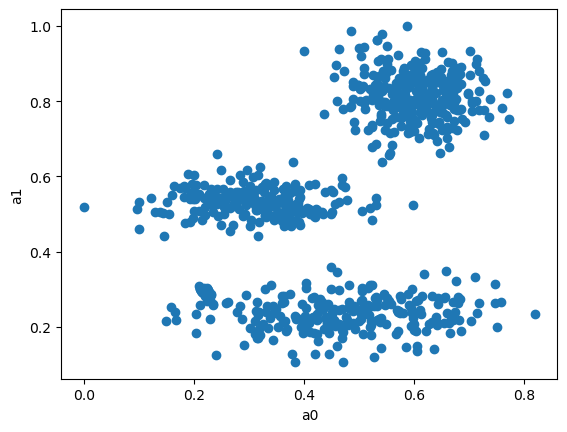

In [113]:
df_0 = df.copy()
df = df.drop(["class"], axis=1)  # Eliminem la columna de classe per a l'agrupament no supervisat

# Normalització de les dades per a l'agrupament no supervisat
df = (df-np.min(df))/(np.max(df)-np.min(df))
x=df[atr_x]
y=df[atr_y]


plt.scatter(x, y)
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()


In [117]:
# Curva de codo (elbow curve) para k-means muestra los errores cuadráticos medios
# para cada valor de k (número de clusters)

scores = []
n = 20 # Número de réplicas
rango_k = range(1,15)
for k in rango_k:
  kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)
  kmeans.fit(df)
  scores.append(kmeans.inertia_)



Codo: k= 3


(0.0, 81.70762942314187)

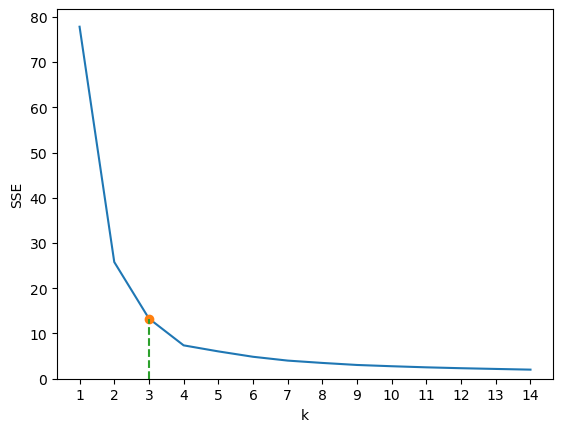

In [ ]:
# Localització del colze per aproximació de la segona derivada.
#
# SSE'' (segona derivada de SSE) s'aproxima per
# SSE''(i) = (SSE(i+1)-SSE(i))-(SSE(i)-SSE(i-1)) = SSE(i+1)+SSE(i-1)-2*SSE(i)
#
# El colze és on el valor absolut de la segona derivada és màxim, és
# dir, on és màxim abs(2*SSE(i)-SSE(i+1)-SSE(i-1))

# Ja hem dit que no és la millor manera, ja que cal utilitzar la silueta, per exemple, però ho deixem així per a mostrar el mètode del colze.

abs_der2 = [0, 0]
for i in range(2, len(scores)-1):
  abs_der2.append(np.abs(2*scores[i]-scores[i+1]-scores[i-1]))

elbow = pd.Series(abs_der2).idxmax() + 1

print("Codo: k=", elbow)

plt.xlabel("k")
plt.ylabel("SSE")
plt.xticks(np.arange(rango_k.start,rango_k.stop,1))
plt.plot(rango_k, scores)
plt.plot(elbow, scores[elbow-1], marker = "o")
plt.plot([elbow, elbow], [0, scores[elbow-1]], linestyle="--")
plt.ylim(ymin=0)

Centroides:
 [[0.60132069 0.81157774]
 [0.28037551 0.44517186]
 [0.49776151 0.23203223]]
Grupo 0:  313 observaciones
Grupo 1:  339 observaciones
Grupo 2:  224 observaciones


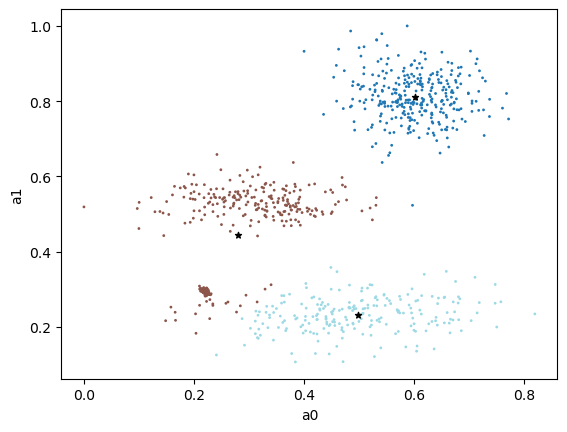

Score: 13.303508


In [121]:
k = 3
n = 20    # Número de réplicas

kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)

kmeans.fit(df)
grupos = kmeans.predict(df)
centroides = kmeans.cluster_centers_

print("Centroides:\n", centroides)

# Mostrar grupos

for i in range(kmeans.n_clusters):
  print("Grupo {:d}: {:4d} observaciones".format(i, sum(grupos==i)))

plt.scatter(x, y, c=grupos, s=1, cmap='tab20')

# Marcar centroides

plt.scatter(centroides[:, 0], centroides[:, 1], marker='*', c='black', s=20)

plt.xlabel(atr_x)
plt.ylabel(atr_y)

plt.show()

print("Score: {:f}".format(kmeans.inertia_))


Es veu que el clúster no és satisfactori amb punts que no semblen correspondre al clúster. El problema és que el grup de baix és molt llarg. Amb un reescalar de `x` passaran a ser més pareguts a `blobs` i millorarà el centroid del grup del mig. 


Centroides:
 [[0.00993939 0.53477297]
 [0.01254667 0.25152236]
 [0.01880241 0.81455431]]
Grupo 0:  223 observaciones
Grupo 1:  345 observaciones
Grupo 2:  308 observaciones


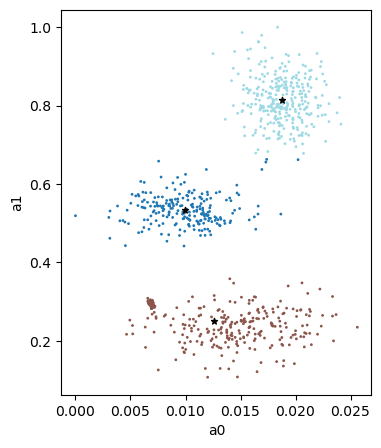

Score: 2.193830


In [126]:
df[atr_x] = df[atr_x]*0.5
x=df[atr_x]
y=df[atr_y]

k = 3
n = 20    # Número de réplicas



kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)

kmeans.fit(df)
grupos = kmeans.predict(df)
centroides = kmeans.cluster_centers_

print("Centroides:\n", centroides)

# Mostrar grupos

for i in range(kmeans.n_clusters):
  print("Grupo {:d}: {:4d} observaciones".format(i, sum(grupos==i)))


fig, ax = plt.subplots(figsize=(4, 5))

ax.scatter(x, y, c=grupos, s=1, cmap='tab20')


# Marcar centroides

ax.scatter(centroides[:, 0], centroides[:, 1], marker='*', c='black', s=20)

ax.set_xlabel(atr_x)
ax.set_ylabel(atr_y)

plt.show()

print("Score: {:f}".format(kmeans.inertia_))


Aquest exemple està molt preparat i sols amb 2 dimensions. No sempre serà tant fàcil. A partir de 4 dimensions no es pot representar, però sempre es pot fer la gràfica del colze SSE i les tècniques més avançades que després veurem.



### Exemple de K-Means en 3D



In [127]:
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

!rm tetra.arff
!wget https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/tetra.arff

rm: no se puede borrar 'tetra.arff': No existe el archivo o el directorio
--2026-07-27 16:44:58--  https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/tetra.arff
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.109.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 12727 (12K) [text/plain]
Guardando como: ‘tetra.arff’

tetra.arff          100%[===================>]  12,43K  --.-KB/s    en 0,001s  

2026-07-27 16:44:58 (10,2 MB/s) - ‘tetra.arff’ guardado [12727/12727]



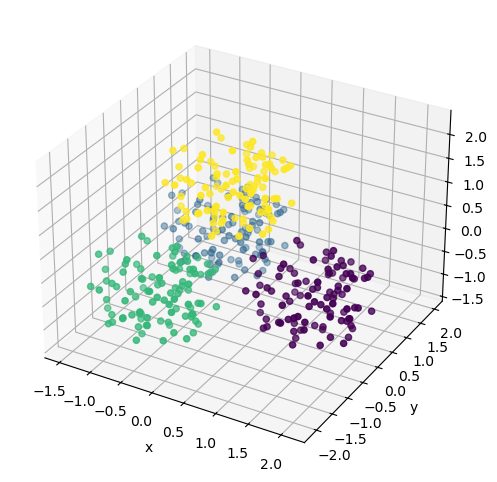

Codo: k= 4


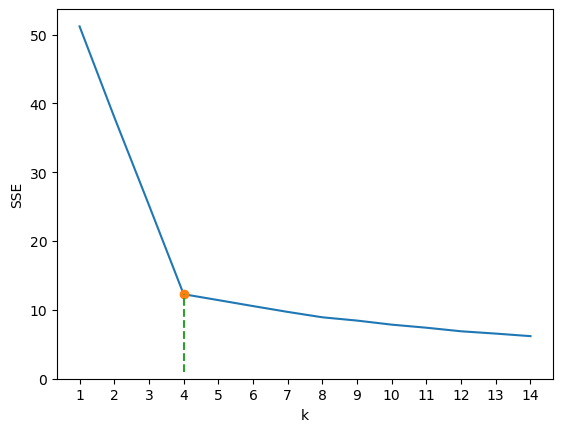

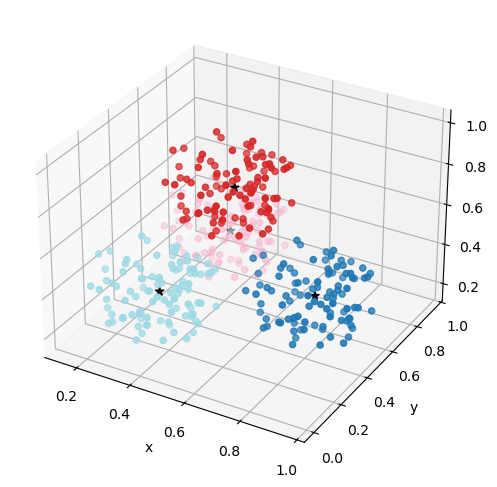

In [132]:
valores, metad = arff.loadarff("tetra.arff")
df = pd.DataFrame(valores)

attr_x='x'
attr_y='y'
attr_z='z'
attr_target='class'

ax = plt.figure().add_subplot(projection = '3d')
plt.gcf().set_size_inches(8, 6)
ax.set_xlabel(attr_x)
ax.set_ylabel(attr_y)
ax.set_zlabel(attr_z)
scatter = ax.scatter(df[attr_x], df[attr_y], df[attr_z], c=df[attr_target])
plt.show()

df_0 = df
df = df.drop(["class"], axis=1)

df = (df-np.min(df))/(np.max(df)-np.min(df))

# Curva de codo (elbow curve) para k-means muestra los errores cuadráticos
# medios para cada valor de k (número de clusters).

RANDOM_SEED = 5
n=20

scores = []
rango_k = range(1,15)
for k in rango_k:
  kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)
  kmeans.fit(df)
  scores.append(kmeans.inertia_)


abs_der2 = [0, 0]
for i in range(2, len(scores)-1):
  abs_der2.append(np.abs(2*scores[i]-scores[i+1]-scores[i-1]))

codo = pd.Series(abs_der2).idxmax() + 1
print("Codo: k=", codo)


plt.xlabel("k")
plt.ylabel("SSE")
plt.xticks(np.arange(rango_k.start,rango_k.stop,1))
plt.plot(rango_k, scores)
plt.plot(codo, scores[codo-1], marker = "o")
plt.plot([codo, codo], [1, scores[codo-1]], linestyle="--")
plt.ylim(ymin=0)

k = 4
n = 20    # Número de réplicas

kmeans = KMeans(n_clusters = k, n_init = n, random_state = RANDOM_SEED, verbose = 0)

kmeans.fit(df)
grupos = kmeans.predict(df)
centroides = kmeans.cluster_centers_

# Gráfico en 3D

attr_x='x'
attr_y='y'
attr_z='z'
attr_target='class'

ax = plt.figure().add_subplot(projection = '3d')
plt.gcf().set_size_inches(8, 6)

ax.set_xlabel(attr_x)
ax.set_ylabel(attr_y)
ax.set_zlabel(attr_z)

scatter = ax.scatter(
  df[attr_x], df[attr_y], df[attr_z],
  c=grupos, cmap='tab20')

# Marcar centroides

scatter = ax.scatter(
  centroides[:, 0], centroides[:, 1], centroides[:, 2],
  marker='*', c='black', s=40)

plt.show()


## DB-SCAN

`DBSCAN (Density-Based Spatial Clustering of Applications with Noise)` és un algorisme basat en la distància, però centrat en la `densitat`. Un dels seus paràmetres ès `ε` (épsilon) que representa el radi d'un circul en torn a un punt. Un altre és `MinPts` que són els número de punts en aquest circul. Aquest algorisme aplicar a un punt detecta els punts `interns`, `abastables` o `outliers`.

* Un punt és `intern` si al menys `MinPts` estàn a una distància màxima de `ε`. Per tant, si hi ha una densitat mínima. 
* Un punt és `abastable` si està a aquesta distància màxima del punt inicial. També si trobem un camí de punts interns fins a aquest punt. 

Alguns punts formen part del clúster perquè són abastables per algun punt, però no tenen la densitat.

https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

### Elecció d'Hiperparàmetres per a BD_Scan

Al no necesitar `blobs` sol ser més robust que `K-Means`, no obstant cal tindre cura dels hiperparàmetres. 

* `MinPTS` ha de ser al menys 3. 
* `MinPTS` deuria ser al menys `P` (la quantitat de dimensions del dataset) + 1. 
* Si tenim molts `outliers` o soroll al dataset, és millor augmentar `MinPTS` a, al menys P*2.
* Es sol calcular amb la distància `euclidea`, però es pot triar. 
* 

**Avantatges**: 

* No cal especificar a priori el número de clústers. Això elimina el problema de utilitzar `SSD` o Siluetes. 
* Pot trobar qualsevol cluster, inclús uns dins d'altres. 
* No li afecten els outliers, simplement els detecta com a soroll. 
* Sols necessita dos hiperparàmetres que es poden trobar amb una gràfica. 
* És quasi completament determinista. 

**Inconvenients**:


* La qualitat dels resultats depen del tipus de distància. Amb altes dimensionalitats pot donar mal resultat l'euclidiana i ser millor la `Manhattan`.
* Amb densitats diverses en cada cluster pot no funcionar bé.
* Necessita normalització i pel problema anterior pot ser complicat trobar un bon `ε`. 


Ejemplo de: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py 

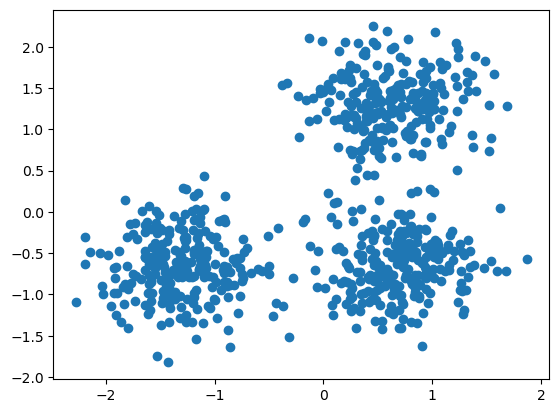

Estimated number of clusters: 3
Estimated number of noise points: 18
Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


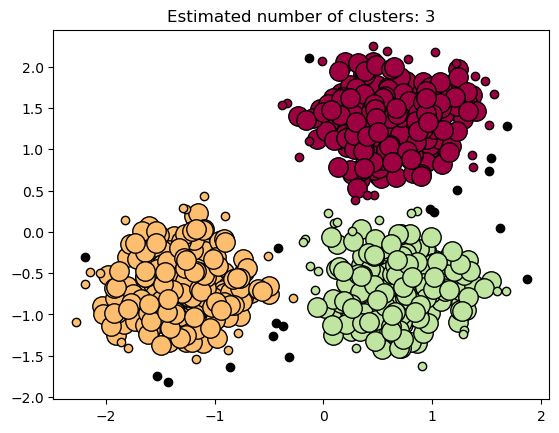

In [135]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

### Exemple complet DB-SCAN

Ho farem amb un altre dataset sintètic amb formes molt diverses i solapades. 

In [136]:
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import DBSCAN

from sklearn import metrics

!rm complex8.arff
!wget https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/complex8.arff

rm: no se puede borrar 'complex8.arff': No existe el archivo o el directorio
--2026-07-27 18:00:44--  https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/complex8.arff
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.108.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 47276 (46K) [text/plain]
Guardando como: ‘complex8.arff’

complex8.arff       100%[===================>]  46,17K  --.-KB/s    en 0,01s   

2026-07-27 18:00:44 (3,21 MB/s) - ‘complex8.arff’ guardado [47276/47276]



<class 'pandas.DataFrame'>
RangeIndex: 2551 entries, 0 to 2550
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       2551 non-null   float64
 1   y       2551 non-null   float64
 2   class   2551 non-null   object 
dtypes: float64(2), object(1)
memory usage: 59.9+ KB


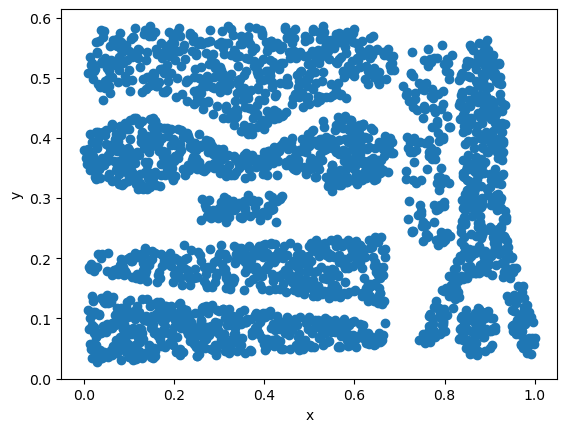

In [142]:
valores, metad = arff.loadarff("complex8.arff")
df = pd.DataFrame(valores)
df.info()
atr_x = "x"
atr_y= "y"

df['class'] = df['class'].str.decode("utf-8")
labels_true = df["class"]
df = df.drop(["class"], axis=1)
df = (df-np.min(df))/(np.max(df)-np.min(df))

x=df[atr_x]
y=df[atr_y]

plt.scatter(x, y)
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()




Número de clusters: 110
Número de outliers: 1580


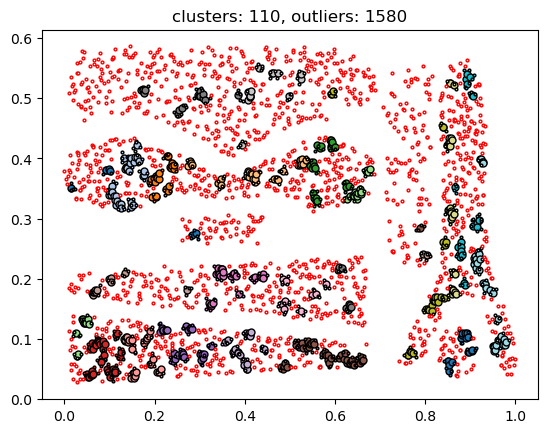

In [144]:
minPts = 5
epsilon = 0.01
db = DBSCAN(eps=epsilon, min_samples=minPts).fit(df[[atr_x,atr_y]])
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Número de clusters: %d" % n_clusters_)
print("Número de outliers: %d" % n_noise_)

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.tab20(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        #col = [0, 0, 0, 1]
        # Blanco con borde rojo para outliers
        col = [1, 1, 1, 1]

    class_member_mask = labels == k

    xy = df[class_member_mask & core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=5,
    )

    xy = df[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor= ("r" if k==-1 else "k"),
        markersize=2,
    )

plt.title(f"clusters: {n_clusters_}, outliers: {n_noise_}")
plt.show()

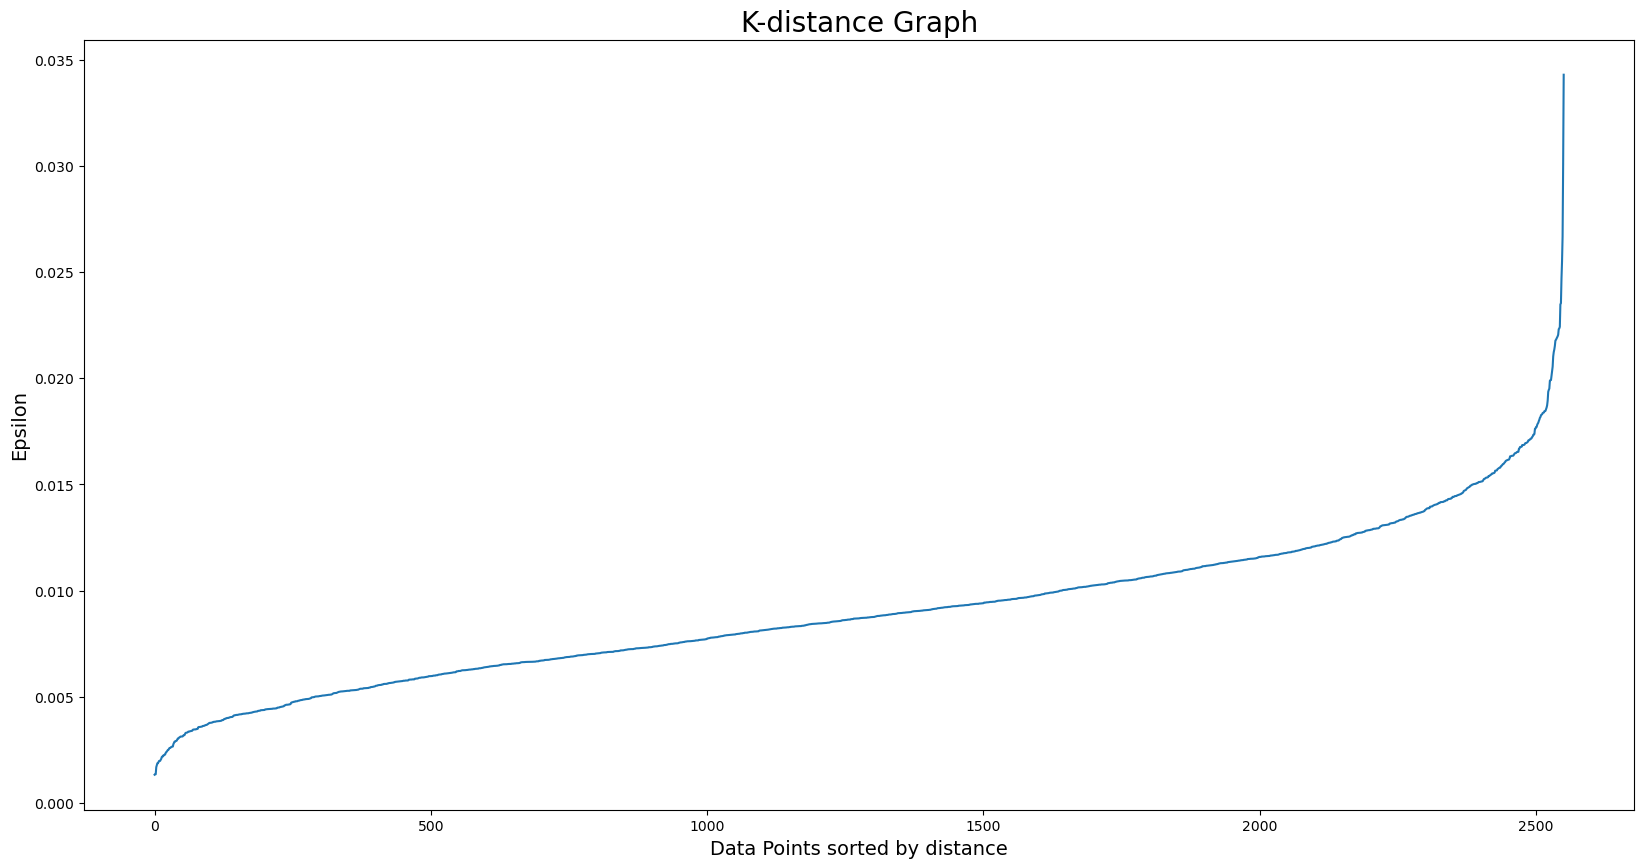

Codo: minPts= 5 , epsilon 0.030083579565779516


In [ ]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=minPts-1)
nbrs = neigh.fit(df)
distances, indices = nbrs.kneighbors()

# Plotting K-distance Graph
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(20,10))
plt.plot(distances)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

# La segona derivada no va a funcionar bé amb aquest conjunt de dades, ja que la corba no és prou suau. Per tant, caldrà ajustar manualment el valor de epsilon.

abs_der2 = [0, 0]
for i in range(2, len(distances)-1):
  abs_der2.append(np.abs(2*distances[i]-distances[i+1]-distances[i-1]))
elbowX = pd.Series(abs_der2).idxmax() + 1

epsilon = distances[elbowX]

print("Codo: minPts=", minPts, ", epsilon", epsilon)

In [ ]:
db = DBSCAN(eps=0.025, min_samples=minPts).fit(df[[atr_x,atr_y]]) 
labels = db.labels_

# Number of clusters in labels, ignorng noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Número de clusters: %d" % n_clusters_)
print("Número de outliers: %d" % n_noise_)


Número de clusters: 8
Número de outliers: 3


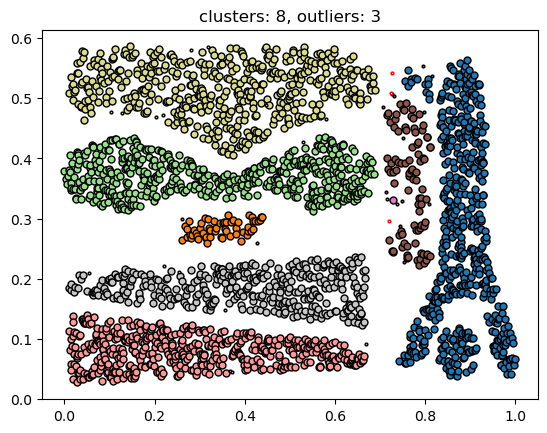

In [155]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.tab20(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        #col = [0, 0, 0, 1]
        # Blanco con borde rojo para outliers
        col = [1, 1, 1, 1]

    class_member_mask = labels == k

    xy = df[class_member_mask & core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=5,
    )

    xy = df[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor= ("r" if k==-1 else "k"),
        markersize=2,
    )

plt.title(f"clusters: {n_clusters_}, outliers: {n_noise_}")
plt.show()

## Clustering Jeràrquic

## Gaussian Mixture Models (GMM)



## Validació, mètriques i càlcul d'Hiperparàmetres



## Reducció de la dimensionalitat